In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [2]:
# ==========================================
# Traffic Signal Timing Optimization Using AI Deep Learning
# ==========================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("All libraries imported successfully!")
print("TensorFlow Version:", tf.__version__)

All libraries imported successfully!
TensorFlow Version: 2.21.0


In [3]:
import os

# Search for Traffic.csv in your Downloads folder
for root, dirs, files in os.walk(r"C:\Users\gayat\Downloads"):
    for file in files:
        if file.lower() == "traffic.csv":
            print(os.path.join(root, file))

C:\Users\gayat\Downloads\TFOP_dataset\Traffic.csv


In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"C:\Users\gayat\Downloads\TFOP_dataset\Traffic.csv")

# Display the first 5 rows
df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


In [5]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# General information
print("\nDataset Information:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2976, 9)

Columns:
Index(['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total', 'Traffic Situation'],
      dtype='object')

Data Types:
Time                 object
Date                  int64
Day of the week      object
CarCount              int64
BikeCount             int64
BusCount              int64
TruckCount            int64
Total                 int64
Traffic Situation    object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-null   object
 3   CarCount           2976 non-null   int64 
 4   BikeCount          2976 non-null   int64 
 5   BusCount           2976 non-null   int64 
 6   TruckCount         2976 

In [6]:
# Statistical summary of numerical columns
df.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000
mean,16.000000,68.696573,14.917339,15.279570,15.324933,114.218414
std,8.945775,45.850693,12.847518,14.341986,10.603833,60.190627
min,1.000000,6.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,19.000000,5.000000,1.000000,6.000000,55.000000
50%,16.000000,64.000000,12.000000,12.000000,14.000000,109.000000
75%,24.000000,107.000000,22.000000,25.000000,23.000000,164.000000
max,31.000000,180.000000,70.000000,50.000000,40.000000,279.000000


In [7]:
# Check unique values in each column
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique())


Time
['12:00:00 AM' '12:15:00 AM' '12:30:00 AM' '12:45:00 AM' '1:00:00 AM'
 '1:15:00 AM' '1:30:00 AM' '1:45:00 AM' '2:00:00 AM' '2:15:00 AM'
 '2:30:00 AM' '2:45:00 AM' '3:00:00 AM' '3:15:00 AM' '3:30:00 AM'
 '3:45:00 AM' '4:00:00 AM' '4:15:00 AM' '4:30:00 AM' '4:45:00 AM'
 '5:00:00 AM' '5:15:00 AM' '5:30:00 AM' '5:45:00 AM' '6:00:00 AM'
 '6:15:00 AM' '6:30:00 AM' '6:45:00 AM' '7:00:00 AM' '7:15:00 AM'
 '7:30:00 AM' '7:45:00 AM' '8:00:00 AM' '8:15:00 AM' '8:30:00 AM'
 '8:45:00 AM' '9:00:00 AM' '9:15:00 AM' '9:30:00 AM' '9:45:00 AM'
 '10:00:00 AM' '10:15:00 AM' '10:30:00 AM' '10:45:00 AM' '11:00:00 AM'
 '11:15:00 AM' '11:30:00 AM' '11:45:00 AM' '12:00:00 PM' '12:15:00 PM'
 '12:30:00 PM' '12:45:00 PM' '1:00:00 PM' '1:15:00 PM' '1:30:00 PM'
 '1:45:00 PM' '2:00:00 PM' '2:15:00 PM' '2:30:00 PM' '2:45:00 PM'
 '3:00:00 PM' '3:15:00 PM' '3:30:00 PM' '3:45:00 PM' '4:00:00 PM'
 '4:15:00 PM' '4:30:00 PM' '4:45:00 PM' '5:00:00 PM' '5:15:00 PM'
 '5:30:00 PM' '5:45:00 PM' '6:00:00 PM' '6:15:00 PM' '

In [8]:
# Count of each traffic situation
print(df["Traffic Situation"].value_counts())

Traffic Situation
normal    1669
heavy      682
high       321
low        304
Name: count, dtype: int64


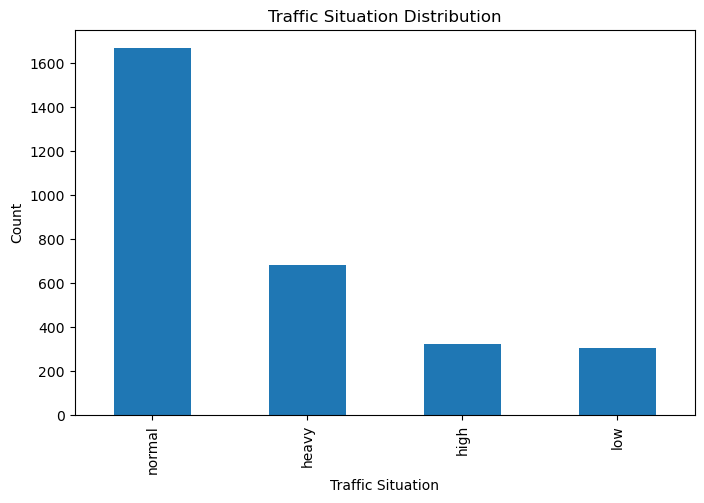

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df["Traffic Situation"].value_counts().plot(kind="bar")
plt.title("Traffic Situation Distribution")
plt.xlabel("Traffic Situation")
plt.ylabel("Count")
plt.show()

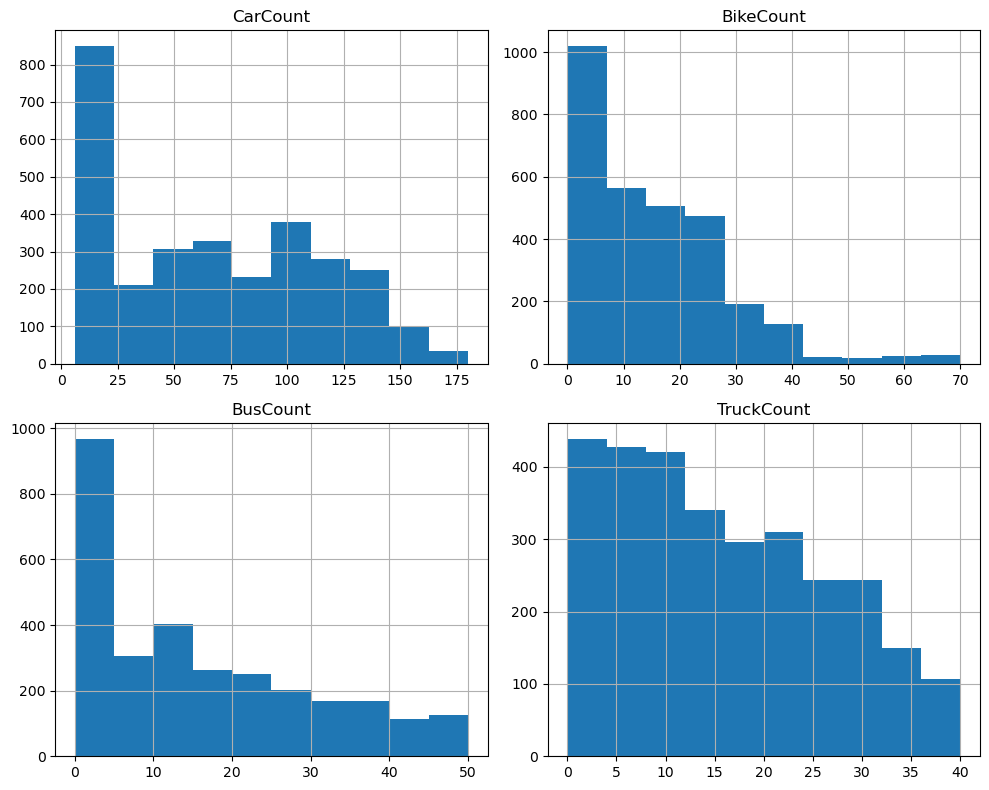

In [10]:
vehicle_columns = ["CarCount", "BikeCount", "BusCount", "TruckCount"]

df[vehicle_columns].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [11]:
print(df.columns)

Index(['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total', 'Traffic Situation'],
      dtype='object')


In [12]:
print(df.head())

          Time  Date Day of the week  CarCount  BikeCount  BusCount  \
0  12:00:00 AM    10         Tuesday        31          0         4   
1  12:15:00 AM    10         Tuesday        49          0         3   
2  12:30:00 AM    10         Tuesday        46          0         3   
3  12:45:00 AM    10         Tuesday        51          0         2   
4   1:00:00 AM    10         Tuesday        57          6        15   

   TruckCount  Total Traffic Situation  
0           4     39               low  
1           3     55               low  
2           6     55               low  
3           5     58               low  
4          16     94            normal  


In [13]:
# Convert Time to datetime
df["Time"] = pd.to_datetime(df["Time"], format="%I:%M:%S %p")

# Create Hour feature
df["Hour"] = df["Time"].dt.hour

# Verify
df[["Time", "Hour"]].head()

,Time,Hour
0,1900-01-01 00:00:00,0
1,1900-01-01 00:15:00,0
2,1900-01-01 00:30:00,0
3,1900-01-01 00:45:00,0
4,1900-01-01 01:00:00,1


In [14]:
from sklearn.preprocessing import LabelEncoder

# Encode Day of the week
day_encoder = LabelEncoder()
df["Day of the week"] = day_encoder.fit_transform(df["Day of the week"])

# Encode Traffic Situation
traffic_encoder = LabelEncoder()
df["Traffic Situation"] = traffic_encoder.fit_transform(df["Traffic Situation"])

df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,Hour
0,1900-01-01 00:00:00,10,5,31,0,4,4,39,2,0
1,1900-01-01 00:15:00,10,5,49,0,3,3,55,2,0
2,1900-01-01 00:30:00,10,5,46,0,3,6,55,2,0
3,1900-01-01 00:45:00,10,5,51,0,2,5,58,2,0
4,1900-01-01 01:00:00,10,5,57,6,15,16,94,3,1


In [15]:
X = df[[
    "CarCount",
    "BikeCount",
    "BusCount",
    "TruckCount",
    "Total",
    "Hour",
    "Day of the week"
]]

y = df["Traffic Situation"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2976, 7)
Target Shape: (2976,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (2380, 7)
Testing Data : (596, 7)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preprocessing completed successfully.")

Data preprocessing completed successfully.


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Create the model
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(len(set(y)), activation='softmax'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

C:\Users\gayat\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,724 (10.64 KB)

 Trainable params: 2,724 (10.64 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6397 - loss: 0.9768 - val_accuracy: 0.7332 - val_loss: 0.7007
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7495 - loss: 0.6576 - val_accuracy: 0.7815 - val_loss: 0.5192
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8136 - loss: 0.5071 - val_accuracy: 0.8424 - val_loss: 0.4184
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8398 - loss: 0.4287 - val_accuracy: 0.8592 - val_loss: 0.3627
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8508 - loss: 0.3893 - val_accuracy: 0.8908 - val_loss: 0.3168
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8661 - loss: 0.3709 - val_accuracy: 0.9034 - val_loss: 0.2904
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8729 - loss: 0.3393 - val_accuracy: 0.8866 - val_loss: 0.2731
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8718 - loss: 0.3286 - val_accuracy: 0.9139 - val_loss


KeyboardInterrupt



In [20]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9362 - loss: 0.1866
Test Loss : 0.18655680119991302
Test Accuracy : 0.936241626739502


In [45]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9189 - loss: 0.2089 - val_accuracy: 0.9329 - val_loss: 0.1823
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9248 - loss: 0.2023 - val_accuracy: 0.9312 - val_loss: 0.1808
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9235 - loss: 0.1995 - val_accuracy: 0.9346 - val_loss: 0.1765
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9282 - loss: 0.1991 - val_accuracy: 0.9396 - val_loss: 0.1711
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9357 - loss: 0.1874 - val_accuracy: 0.9446 - val_loss: 0.1667
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9235 - loss: 0.1924 - val_accuracy: 0.9362 - val_loss: 0.1681
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9244 - loss: 0.1995 - val_accuracy: 0.9279 - val_loss: 0.1758
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9290 - loss: 0.1935 - val_accuracy: 0.9430 - val_loss:

In [47]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9496 - loss: 0.1379 - val_accuracy: 0.9446 - val_loss: 0.1270
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9483 - loss: 0.1417 - val_accuracy: 0.9547 - val_loss: 0.1253
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9550 - loss: 0.1337 - val_accuracy: 0.9581 - val_loss: 0.1236
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9534 - loss: 0.1371 - val_accuracy: 0.9547 - val_loss: 0.1189
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9525 - loss: 0.1360 - val_accuracy: 0.9564 - val_loss: 0.1204
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9563 - loss: 0.1289 - val_accuracy: 0.9530 - val_loss: 0.1215
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9487 - loss: 0.1372 - val_accuracy: 0.9530 - val_loss: 0.1210
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9492 - loss: 0.1337 - val_accuracy: 0.9547 - val_loss:

In [24]:
# Predict probabilities for the test set
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
import numpy as np

y_pred = np.argmax(y_pred_prob, axis=1)

print(y_pred[:10])

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[1 0 2 2 3 2 0 2 3 3]


In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9362416107382551

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       137
           1       0.87      0.73      0.80        64
           2       0.95      0.92      0.93        61
           3       0.96      0.96      0.96       334

    accuracy                           0.94       596
   macro avg       0.92      0.90      0.91       596
weighted avg       0.94      0.94      0.94       596


Confusion Matrix
[[135   2   0   0]
 [ 10  47   0   7]
 [  0   0  56   5]
 [  6   5   3 320]]


In [26]:
# Example input
new_data = [[80, 20, 10, 5, 115, 18, 1]]
# [CarCount, BikeCount, BusCount, TruckCount, Total, Hour, Day of the week]

# Scale the input
new_data = scaler.transform(new_data)

# Predict
prediction = model.predict(new_data)

predicted_class = np.argmax(prediction, axis=1)[0]

print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicted Class: 3


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [27]:
predicted_traffic = traffic_encoder.inverse_transform([predicted_class])[0]

print("Predicted Traffic Situation:", predicted_traffic)

Predicted Traffic Situation: normal


In [28]:
if predicted_traffic == "low":
    green_time = 20

elif predicted_traffic == "normal":
    green_time = 40

elif predicted_traffic == "high":
    green_time = 60

elif predicted_traffic == "heavy":
    green_time = 90

else:
    green_time = 30

print("Traffic Situation :", predicted_traffic)
print("Recommended Green Signal Time :", green_time, "seconds")

Traffic Situation : normal
Recommended Green Signal Time : 40 seconds


In [29]:
# Total number of vehicles
total_vehicles = 80 + 20 + 10 + 5   # Replace these with your input values if needed

# Dynamic Green Signal Timing
if predicted_traffic == "low":
    green_time = 20 + (total_vehicles * 0.10)

elif predicted_traffic == "normal":
    green_time = 35 + (total_vehicles * 0.15)

elif predicted_traffic == "high":
    green_time = 50 + (total_vehicles * 0.20)

elif predicted_traffic == "heavy":
    green_time = 70 + (total_vehicles * 0.25)

# Limit between 20 and 120 seconds
green_time = max(20, min(120, green_time))

print("Traffic Situation :", predicted_traffic)
print("Total Vehicles :", total_vehicles)
print("Recommended Green Signal Time :", round(green_time), "seconds")

Traffic Situation : normal
Total Vehicles : 115
Recommended Green Signal Time : 52 seconds


In [30]:
# Save the trained model
model.save("Traffic_Signal_Optimization_Model.keras")

print("Model saved successfully!")

Model saved successfully!


In [31]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [32]:
joblib.dump(traffic_encoder, "traffic_encoder.pkl")

print("Traffic encoder saved successfully!")

Traffic encoder saved successfully!


In [33]:
# Example input
car = 120
bike = 35
bus = 15
truck = 10
hour = 18
day = 1

total = car + bike + bus + truck

sample = [[car, bike, bus, truck, total, hour, day]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

predicted_traffic = traffic_encoder.inverse_transform([predicted_class])[0]

print("Predicted Traffic:", predicted_traffic)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Predicted Traffic: heavy


In [34]:
if predicted_traffic == "low":
    green_time = 20 + total * 0.10
elif predicted_traffic == "normal":
    green_time = 35 + total * 0.15
elif predicted_traffic == "high":
    green_time = 50 + total * 0.20
else:  # heavy
    green_time = 70 + total * 0.25

green_time = round(max(20, min(120, green_time)))

print("\n========== TRAFFIC SIGNAL OPTIMIZATION ==========")
print("Cars              :", car)
print("Bikes             :", bike)
print("Buses             :", bus)
print("Trucks            :", truck)
print("Total Vehicles    :", total)
print("Predicted Traffic :", predicted_traffic)
print("Green Signal Time :", green_time, "seconds")
print("===============================================")


========== TRAFFIC SIGNAL OPTIMIZATION ==========
Cars              : 120
Bikes             : 35
Buses             : 15
Trucks            : 10
Total Vehicles    : 180
Predicted Traffic : heavy
Green Signal Time : 115 seconds


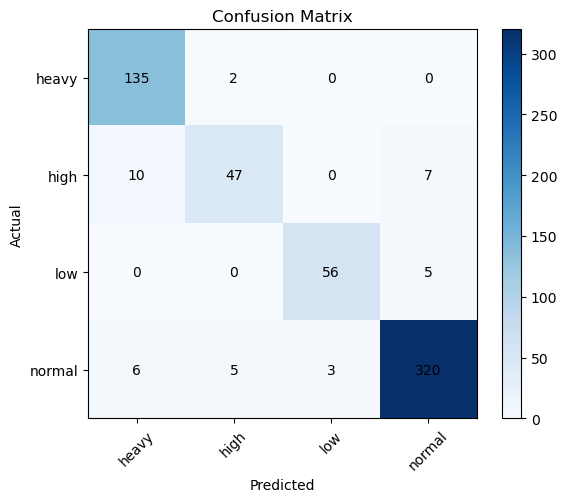

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

classes = traffic_encoder.classes_
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.tight_layout()
plt.show()

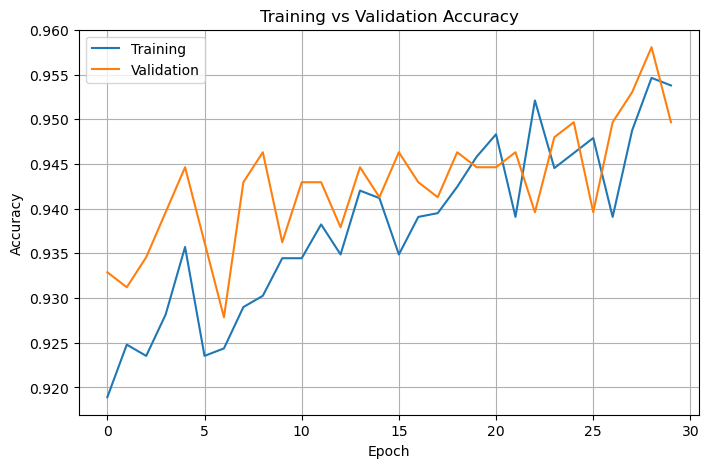

In [46]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])
plt.grid(True)

plt.show()

In [48]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9638 - loss: 0.1067 - val_accuracy: 0.9937 - val_loss: 0.0392
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9627 - loss: 0.1062 - val_accuracy: 0.9958 - val_loss: 0.0389
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9606 - loss: 0.1058 - val_accuracy: 0.9937 - val_loss: 0.0430
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9648 - loss: 0.1054 - val_accuracy: 0.9874 - val_loss: 0.0472
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9622 - loss: 0.1096 - val_accuracy: 0.9937 - val_loss: 0.0450
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9617 - loss: 0.1062 - val_accuracy: 0.9916 - val_loss: 0.0403
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9653 - loss: 0.0999 - val_accuracy: 0.9937 - val_loss: 0.0400
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9674 - loss: 0.1082 - val_accuracy: 0.9937 - val_loss:

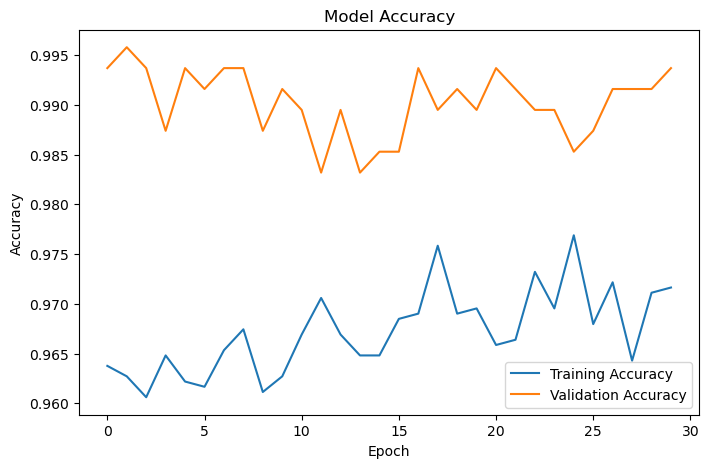

In [49]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

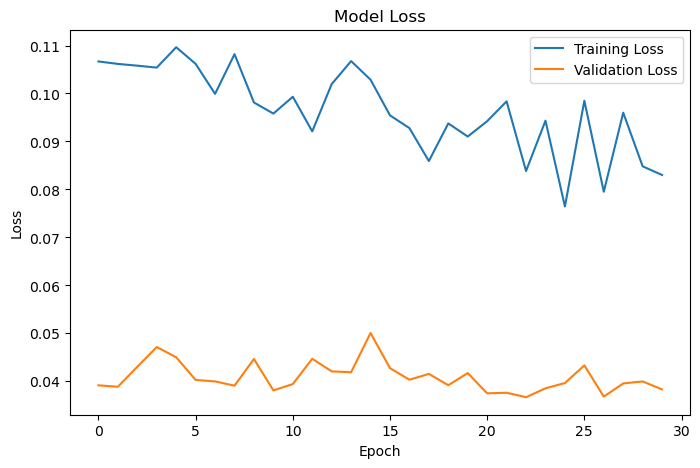

In [50]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [38]:
model.save("Traffic_Signal_Optimization_Model.keras")

print("Deep Learning Model Saved Successfully")

Deep Learning Model Saved Successfully


In [39]:
print("="*60)
print("PROJECT COMPLETED")
print("="*60)

print("Project Title:")
print("Traffic Signal Timing Optimization Using AI Deep Learning")

print("\nProject Features")
print("----------------------------")
print("✔ Traffic Data Analysis")
print("✔ Deep Learning Classification")
print("✔ Traffic Prediction")
print("✔ Dynamic Signal Timing Optimization")
print("✔ Model Evaluation")
print("✔ Model Saving")

print("\nStatus : SUCCESSFULLY COMPLETED")

PROJECT COMPLETED
Project Title:
Traffic Signal Timing Optimization Using AI Deep Learning

Project Features
----------------------------
✔ Traffic Data Analysis
✔ Deep Learning Classification
✔ Traffic Prediction
✔ Dynamic Signal Timing Optimization
✔ Model Evaluation
✔ Model Saving

Status : SUCCESSFULLY COMPLETED


In [51]:
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df.to_csv("training_history.csv", index=False)

print("Training history saved successfully!")

Training history saved successfully!


In [41]:
results = pd.DataFrame({
    "Actual": traffic_encoder.inverse_transform(y_test),
    "Predicted": traffic_encoder.inverse_transform(y_pred)
})

results.head()

,Actual,Predicted
0,high,high
1,heavy,heavy
2,low,low
3,low,low
4,normal,normal


In [42]:
results.to_csv("prediction_results.csv", index=False)

print("Prediction results saved successfully!")

Prediction results saved successfully!


In [43]:
print("="*70)
print("      TRAFFIC SIGNAL TIMING OPTIMIZATION USING AI DEEP LEARNING")
print("="*70)

print(f"Dataset Size            : {df.shape[0]} rows")
print(f"Features Used           : {X.shape[1]}")
print(f"Traffic Classes         : {list(traffic_encoder.classes_)}")
print(f"Test Accuracy           : {accuracy*100:.2f}%")
print(f"Recommended Green Time  : {green_time} seconds")

print("="*70)
print("Project Status : COMPLETED")
print("="*70)

      TRAFFIC SIGNAL TIMING OPTIMIZATION USING AI DEEP LEARNING
Dataset Size            : 2976 rows
Features Used           : 7
Traffic Classes         : ['heavy', 'high', 'low', 'normal']
Test Accuracy           : 93.62%
Recommended Green Time  : 115 seconds
Project Status : COMPLETED


In [52]:
model.save("traffic_signal_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [53]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [54]:
joblib.dump(traffic_encoder, "traffic_encoder.pkl")

print("Label Encoder saved successfully!")

Label Encoder saved successfully!
